# REXAI Project - Session 1

## 1. Importing Libraries and Dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Data Exploration and Visualization

In [ ]:
df = pd.read_csv("data/RH_dataset.csv", sep=";", encoding="utf-8")
df.head()

In [ ]:
df.info()

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=[object]).columns
assert len(num_cols) + len(cat_cols) == df.shape[1], "Some columns are not categorized correctly."

In [ ]:
col_to_category = {}
for col in cat_cols:
    unique_values = df[col].unique().tolist()
    col_to_category[col] = unique_values
    print(f"Column: {col}, Unique Values: {unique_values}")

In [ ]:
# Hot encoding for categorical variables
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
df_encoded.head()

In [ ]:
# Plot on the same figure in grid mode
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easy iteration
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# Show histograms for categorical variables
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5))
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count of {col}")
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Increase figure size for better readability
plt.figure(figsize=(20, 15))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
plt.show()

- Indiquez par exemple si le jeu de données contient des données manquantes, explorez les différentes colonnes (type, modalités, plages de valeurs, cardinal, distributions, etc.). Commenter.
- Exhibez le parcours d’un employé qui a démissionné et celui d’un employé qui n’a pas démissionné. Commenter.
- Affichez la matrice de corrélation. Commenter.
- Toute autre analyse

- Identifier les variables pouvant être considérées comme sensibles ou
proxies, i.e. des variables qui permettent de deviner ou d’inférer des
caractéristiques sensibles (e.g. la variable temps de pause maternité peut
potentiellement révéler le sexe). (Justifier votre réponse et classification)

## Parcours employés
- Exhibez le parcours d’un employé qui a démissionné et celui d’un employé qui n’a pas démissionné.
- Stats sur les employés en fonction du label

In [ ]:
df_resign = df[df.label == 1]
df_no_resign = df[df.label == 0]
df_resign_encoded = df_encoded[df_encoded.label == 1]
df_no_resign_encoded = df_encoded[df_encoded.label == 0]

print(f"Nombre d'employés ayant démissioné: {len(df_resign)}")
print(f"Nombre d'employés n'ayant pas démissioné: {len(df_no_resign)}")

### Comparaison distributions numériques par label

In [ ]:
for col in num_cols.drop(["label","matricule"]):
    
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(
        data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
        x=col,
        hue="label_name",
        common_norm=False
    )
    
    plt.title(f"Distribution de {col} selon le statut")
    plt.show()

### Comparaison médianes et dispersion

In [ ]:
for col in num_cols.drop(["label","matricule"]):

    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
        x="label_name",
        y=col
    )
    
    plt.title(f"{col} par statut")
    plt.show()

### Analyse des variables catégorielles

In [ ]:
for col in cat_cols:
    
    temp = df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"}))
    
    counts = (
        temp.groupby(["label_name", col])
        .size()
        .unstack(fill_value=0)
    )
    
    prop = counts.div(counts.sum(axis=1), axis=0)
    
    prop.T.plot(kind="bar", figsize=(7,4))
    
    plt.title(f"Distribution de {col} selon le statut")
    plt.ylabel("Proportion")
    plt.show()

### Salaire vs. Ancienneté

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df.assign(label_name=df["label"].map({0:"No Resign",1:"Resign"})),
    x="Ancienneté groupe (années)",
    y="Salaire (Euros)",
    hue="label_name"
)

plt.title("Salaire vs ancienneté")
plt.show()

### Profil moyen des démissionnaires

In [ ]:
df_resign.head()

In [ ]:
profile_resign = df_resign.iloc[:, df.columns != 'label'].describe().T
profile_no_resign = df_no_resign.iloc[:, df.columns != 'label'].describe().T

comparison = pd.DataFrame({
    "Resign_mean": profile_resign["mean"],
    "No_resign_mean": profile_no_resign["mean"]
})

comparison["difference"] = comparison["Resign_mean"] - comparison["No_resign_mean"]

comparison.sort_values("difference", key=abs, ascending=False)

Démission dans les 6 mois

In [ ]:
sample_resign = df_resign.sample(random_state=42)
sample_resign

In [ ]:
df_resign[num_cols.drop(["label","matricule", "Etablissement"])].describe()

Pas de démission dans les 6 mois

In [ ]:
sample_no_resign = df_no_resign.sample(random_state=42)
sample_no_resign

In [ ]:
df_no_resign[num_cols.drop(["label","matricule", "Etablissement"])].describe()

## 3.Machine Learning Models

### Logistic Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

**Sans pondérations des labels**

In [ ]:
X = df_encoded.drop(columns=["label", "matricule", "Etablissement"])
y = df_encoded.label

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Sans pondérer les classes, le classifier prédit tous les labels à 0 (ce qui est souvent vrai étant donné la forte présence de label=0)

**Sans one-hot encoding _Etablissement_**

In [ ]:
X = df_encoded.drop(columns=["label", "matricule", "Etablissement"])
y = df_encoded.label

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

**Avec one-hot encoding _Etablissement_**

In [ ]:
X_etablissement = pd.get_dummies(df_encoded, columns=["Etablissement"], drop_first=False, dtype=int)
X = X_etablissement.drop(columns=["label", "matricule"])
y = df_encoded.label

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

Le fait d'ajouter l'établissement permet d'améliorer légèrement le recall, sans dégrader les autres indicateurs.

Au global, on a une très mauvaise précision sur la classe 1 (démission). Cela peut s'expliquer pas la faible proportion de label 1.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

def fairness_evaluation_with_trueDI(y_true, y_pred, X, age_bins=[20,40,60,80,100]):    
    df_eval = X.copy()
    df_eval['y_true'] = y_true
    df_eval['y_pred'] = y_pred
    
    # Tranches d'âge
    age_labels = [f"{age_bins[i]}-{age_bins[i+1]}" for i in range(len(age_bins)-1)]
    df_eval['Âge (années)'] = pd.cut(df_eval['Âge (années)'], bins=age_bins, labels=age_labels)
    
    results = {}
    
    # Sous-groupes
    subgroups = {
        'Parent': df_eval['Parent'].unique(),
        'Âge (années)': df_eval['Âge (années)'].unique()
    }
    
    # Calcul metrics
    for group_col, groups in subgroups.items():
        metrics = []
        privileged_group = groups[0]  # référence pour DI
        
        for g in groups:
            sub = df_eval[df_eval[group_col]==g]
            if len(sub)==0:
                continue
            
            # FPR / FNR
            tn, fp, fn, tp = confusion_matrix(sub['y_true'], sub['y_pred'], labels=[0,1]).ravel()
            fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
            fnr = fn / (fn + tp) if (fn + tp) > 0 else np.nan
            
            # Disparate Impact sur prédiction
            p_priv_pred = df_eval[df_eval[group_col]==privileged_group]['y_pred'].mean()
            p_unpriv_pred = sub['y_pred'].mean()
            di_pred = p_unpriv_pred / p_priv_pred if p_priv_pred > 0 else np.nan
            
            # Disparate Impact sur vrai label
            p_priv_true = df_eval[df_eval[group_col]==privileged_group]['y_true'].mean()
            p_unpriv_true = sub['y_true'].mean()
            di_true = p_unpriv_true / p_priv_true if p_priv_true > 0 else np.nan
            
            metrics.append({
                'group': g,
                'count': len(sub),
                'FPR': fpr,
                'FNR': fnr,
                'DI_pred': di_pred,
                'DI_true': di_true
            })
        
        results[group_col] = pd.DataFrame(metrics)
    
    return results

In [ ]:
results = fairness_evaluation_with_trueDI(y_test, y_pred, X_test[['Parent','Âge (années)']])

for group_col, df_metrics in results.items():
    print(f"\n{group_col}")
    print(df_metrics.to_string(index=False))

Le modèle semble d'avantage discriminer les 20-40 ans par rapport à la réalité (5 fois plus de démission que les 40-60 ans prédit, contre seulement 3 fois plus en réalité).
Il discrimine aussi plus les parents.

**Explication post-hoc**

In [ ]:
logreg_model = pipeline.named_steps["model"]

coef = logreg_model.coef_[0]
features = X_train.columns

n=len(y_test)
residuals = y_test - y_pred
residual_sum_of_squares = residuals.T @ residuals
sigma_squared_hat = residual_sum_of_squares / (n - 2)
var_beta = np.array([1/np.sum([(X_test[col].to_numpy()[j] - np.mean(X_test[col]))**2 for j in range(n)]) * sigma_squared_hat for col in features])
SE_beta = np.sqrt(var_beta)
t_beta = coef/SE_beta

print(f"{'Feature':<40} {'Weight':>12} {'SE':>12} {'|t|':>12}")
print("-" * 60)

for col, i in zip(features, range(len(features))):
    print(f"{col:<40} {coef[i]:>12.6f} {SE_beta[i]:>12.6f} {abs(t_beta[i]):>12.6f}")

On observe un impact très fort des features suivantes :
- Dernière promotion
- Dernière augmentation
- Début du contrat
- Ancienneté
- Âge
- Salaire

In [ ]:
X = df_encoded[["Dernière promotion (mois)", "Dernière augmentation (mois)", "Début de contrat (années)", "Ancienneté groupe (années)", "Âge (années)", "Salaire (Euros)"]]
y = df_encoded.label

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

On arrive à garder des bonnes performances avec un modèle à seulement 6 features (contre 61 dans le modèle avec le one-hot encoding de Etablissement).

# Part 3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import re
import string
from tqdm import tqdm
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

In [ ]:
# !python -m spacy download en_core_web_sm

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df_raw = pd.read_csv("data/all_data_with_identities.csv", encoding="utf-8")
df = df_raw[["comment_text", "toxicity", "split",
             "male", "female", "transgender", "other_gender",
             "black", "white", "asian", "latino", "other_race_or_ethnicity",
             "heterosexual", "homosexual_gay_or_lesbian", "bisexual", "other_sexual_orientation"]]
df['is_toxic'] = df['toxicity'] >= 0.5
df['text_len'] = df['comment_text'].astype(str).apply(len)

# df_train = df[df.split=="train"].drop(columns=["split"])
# df_test = df[df.split=="test"].drop(columns=["split"])
# df_val = df[df.split=="val"].drop(columns=["split"])

/tmp/ipykernel_85053/559476376.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_toxic'] = df['toxicity'] >= 0.5
/tmp/ipykernel_85053/559476376.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['text_len'] = df['comment_text'].astype(str).apply(len)


## Analyse des données

Distribution de longueurs des textes

In [4]:
print(df['text_len'].describe())

count    448000.000000
mean        351.742958
std         289.323717
min           1.000000
25%         121.000000
50%         257.000000
75%         512.000000
max        1891.000000
Name: text_len, dtype: float64


Distribution des longueurs de textes par toxicité

In [5]:
print(df.groupby('is_toxic')['text_len'].describe())

             count        mean         std  min    25%    50%    75%     max
is_toxic                                                                    
False     397206.0  355.287999  292.107289  1.0  121.0  260.0  521.0  1891.0
True       50794.0  324.020947  264.927574  3.0  122.0  238.0  448.0  1000.0


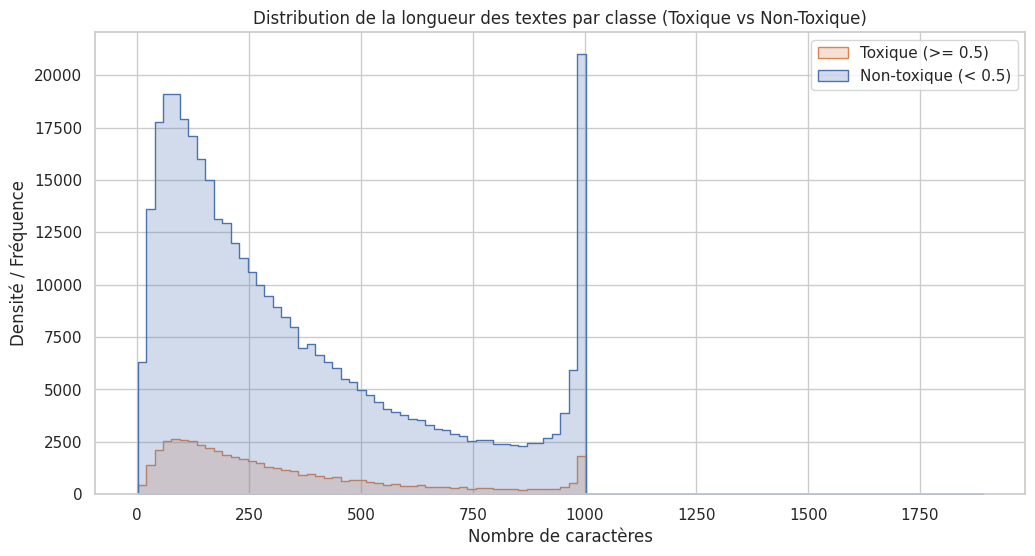

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='text_len', hue='is_toxic', element='step', common_norm=False, bins=100)
plt.title('Distribution de la longueur des textes par classe (Toxique vs Non-Toxique)')
plt.xlabel('Nombre de caractères')
plt.ylabel('Densité / Fréquence')
plt.legend(labels=['Toxique (>= 0.5)', 'Non-toxique (< 0.5)'])
plt.show()

On observe la même tendance dans les deux classes à savoir une majorité de messages courts. Le dataset est plutôt déséquilibré sur la répartition entre la classe toxique et la classe non-toxique : 89% des textes sont classifiés comme étant non-toxiques, pour seulement 11% de textes toxiques.

Cependant, les textes toxiques sont en moyenne plus court de 30 caractères, soit environ 10% de caractères en moins.

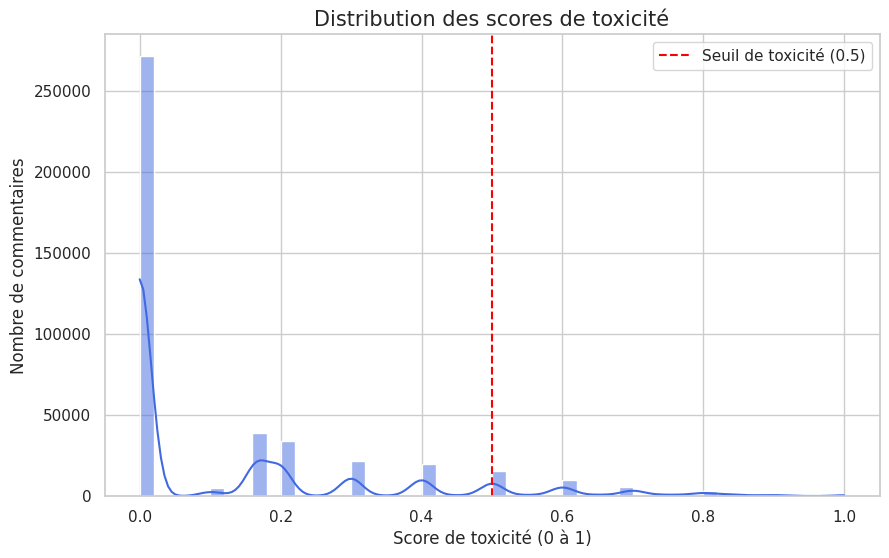

In [7]:
plt.figure(figsize=(10, 6))

sns.histplot(df['toxicity'], bins=50, kde=True, color='royalblue')

plt.axvline(x=0.5, color='red', linestyle='--', label='Seuil de toxicité (0.5)')

plt.title('Distribution des scores de toxicité', fontsize=15)
plt.xlabel('Score de toxicité (0 à 1)', fontsize=12)
plt.ylabel('Nombre de commentaires', fontsize=12)
plt.legend()

plt.show()

On observe une distribution décroissante de la toxicité, avec 60% des textes ayant une toxicité nulle.

## Prétraitement et visualisation

In [ ]:
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

In [94]:
def preprocess_text(text):
    text = text.lower()
    
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    
    text = re.sub(r'@\w+|#\w+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))
    
    text = re.sub(r'\s+', ' ', text).strip()
    
    doc = nlp(text)

    tokens = [token.text for token in doc if not token.is_space]
    
    return tokens

In [98]:
df_val = df[df.split=="val"]

In [99]:
tqdm.pandas()

df_val['tokens'] = df_val['comment_text'].progress_apply(preprocess_text)
df_val['token_count'] = df_val['tokens'].apply(len)

Début du pré-traitement...


100%|██████████| 45180/45180 [03:46<00:00, 199.75it/s]
/tmp/ipykernel_85053/3192152063.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['tokens'] = df_val['comment_text'].progress_apply(preprocess_text)
/tmp/ipykernel_85053/3192152063.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['token_count'] = df_val['tokens'].apply(len)


Statistiques sur le nombre de tokens :
count    45180.000000
mean        61.155135
std         49.884025
min          0.000000
25%         21.000000
50%         45.000000
75%         89.000000
max        359.000000
Name: token_count, dtype: float64


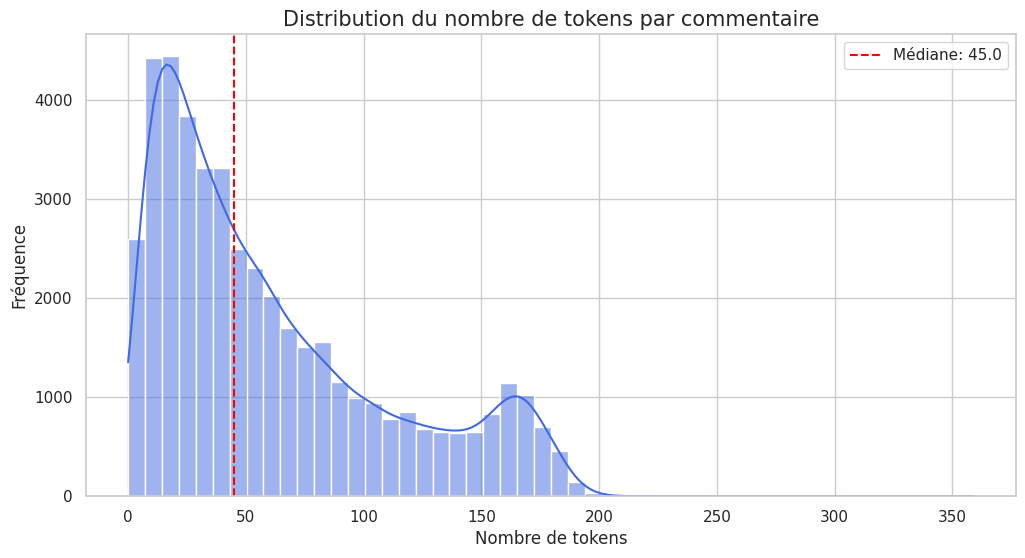

In [103]:
print("Statistiques sur le nombre de tokens :")
print(df_val['token_count'].describe())

plt.figure(figsize=(12, 6))
sns.histplot(df_val['token_count'], bins=50, kde=True, color='royalblue')

plt.title('Distribution du nombre de tokens par commentaire', fontsize=15)
plt.xlabel('Nombre de tokens')
plt.ylabel('Fréquence')
plt.axvline(df_val['token_count'].median(), color='red', linestyle='--', label=f'Médiane: {df_val["token_count"].median()}')
plt.legend()
plt.show()

In [105]:
def lemmatize_pipe(texts):
    lemmas_list = []
    for doc in nlp.pipe(texts, batch_size=500, disable=["parser", "ner"]):
        lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space]
        lemmas_list.append(lemmas)
    return lemmas_list

In [124]:
df_val['lemmas'] = lemmatize_pipe(df_val['comment_text'].astype(str))

/tmp/ipykernel_85053/2333223040.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_val['lemmas'] = lemmatize_pipe(df_val['comment_text'].astype(str))


In [ ]:
df_toxic = df_val[df_val['is_toxic'] == True]
df_non_toxic = df_val[df_val['is_toxic'] == False]

cleaned_stopwords = set(STOPWORDS)

def get_corpus(dataframe):
    
    all_lemmas = [lemma for sublist in dataframe['lemmas'] for lemma in sublist if lemma not in cleaned_stopwords and len(lemma) > 1]
    return " ".join(all_lemmas), all_lemmas

corpus_toxic, lemmas_toxic = get_corpus(df_toxic)
corpus_non_toxic, lemmas_non_toxic = get_corpus(df_non_toxic)

print(f"Nombre de lemmes (toxiques): {len(lemmas_toxic)}")
print(f"Nombre de lemmes (non-toxiques): {len(lemmas_non_toxic)}")

Nombre de lemmes (toxiques): 146400
Nombre de lemmes (non-toxiques): 1254197


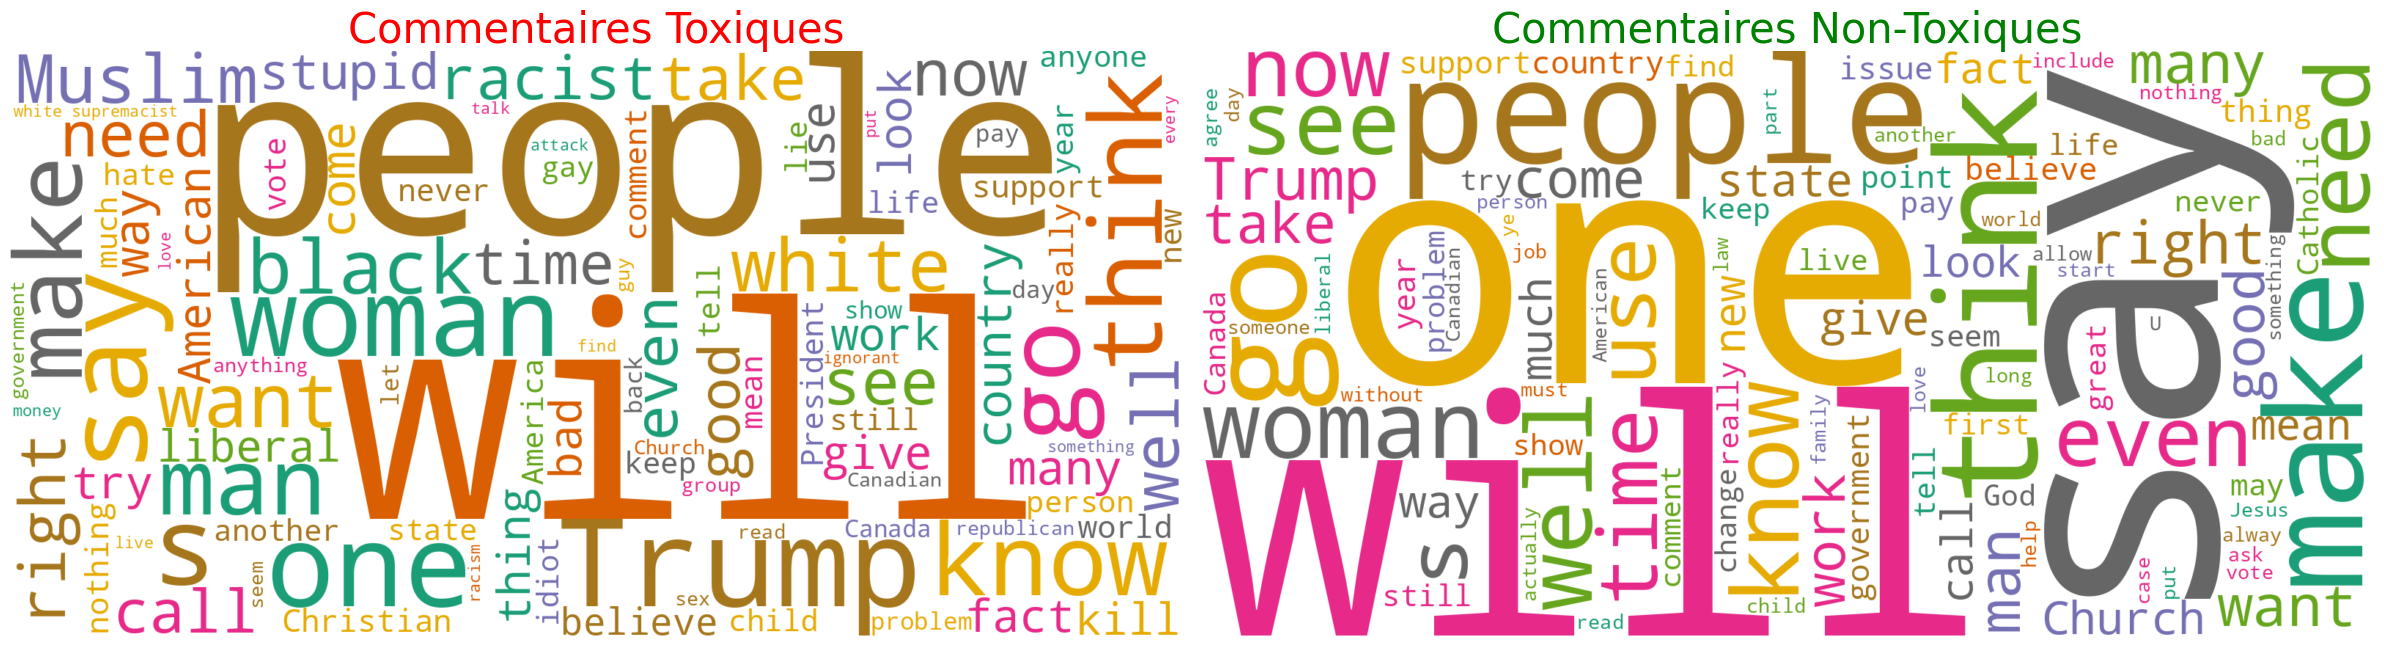

In [143]:
wc_params = {
    'width': 1600,
    'height': 800,
    'background_color': 'white',
    'max_words': 100,
    'colormap': 'Dark2',
    'prefer_horizontal': 0.7
}

wc_toxic = WordCloud(**wc_params).generate(corpus_toxic)
wc_non_toxic = WordCloud(**wc_params).generate(corpus_non_toxic)

fig, ax = plt.subplots(1, 2, figsize=(24, 12))

ax[0].imshow(wc_toxic, interpolation='bilinear')
ax[0].set_title('Commentaires Toxiques', fontsize=30, color='red')
ax[0].axis('off')

ax[1].imshow(wc_non_toxic, interpolation='bilinear')
ax[1].set_title('Commentaires Non-Toxiques', fontsize=30, color='green')
ax[1].axis('off')

plt.tight_layout()
plt.show()

Les mots qui apparaissent fréquemment dans les deux classes sont : 's, Trump, go, know, make, man, one, people, right, say, see, think, well, will, woman

### TF-IDF

In [148]:
corpus = df_val['lemmas'].apply(lambda x: " ".join(x) if isinstance(x, list) else "")

vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Taille de la matrice TF-IDF : {tfidf_matrix.shape}")

Taille de la matrice TF-IDF : (45180, 10000)


In [ ]:
mask_toxic = df_val['is_toxic'] == True
mask_non_toxic = df_val['is_toxic'] == False

mean_tfidf_toxic = tfidf_matrix[mask_toxic.values].mean(axis=0).A1
mean_tfidf_non_toxic = tfidf_matrix[mask_non_toxic.values].mean(axis=0).A1

df_tfidf_comparison = pd.DataFrame({
    'terme': feature_names,
    'tfidf_moyen_toxique': mean_tfidf_toxic,
    'tfidf_moyen_non_toxique': mean_tfidf_non_toxic
})

df_tfidf_comparison['diff_toxicite'] = df_tfidf_comparison['tfidf_moyen_toxique'] - df_tfidf_comparison['tfidf_moyen_non_toxique']

In [155]:
MIN_TFIDF = 0.0005

unique_toxic = df_tfidf_comparison[
    (df_tfidf_comparison['tfidf_moyen_toxique'] > MIN_TFIDF) & 
    (df_tfidf_comparison['tfidf_moyen_non_toxique'] < (MIN_TFIDF / 5))
].sort_values(by='tfidf_moyen_toxique', ascending=False)

unique_non_toxic = df_tfidf_comparison[
    (df_tfidf_comparison['tfidf_moyen_non_toxique'] > MIN_TFIDF) & 
    (df_tfidf_comparison['tfidf_moyen_toxique'] < (MIN_TFIDF / 5))
].sort_values(by='tfidf_moyen_non_toxique', ascending=False)

print(f"Nombre de termes spécifiques à la toxicité : {len(unique_toxic)}")
print(f"Nombre de termes spécifiques au non-toxique : {len(unique_non_toxic)}")

Nombre de termes spécifiques à la toxicité : 46
Nombre de termes spécifiques au non-toxique : 13


In [182]:
print("--- SIGNATURES DE LA TOXICITÉ (Exclusifs) ---")
print(unique_toxic[['terme', 'tfidf_moyen_toxique']])

print("\n--- SIGNATURES DU NON-TOXIQUE (Exclusifs) ---")
print(unique_non_toxic[['terme', 'tfidf_moyen_non_toxique']])

--- SIGNATURES DE LA TOXICITÉ (Exclusifs) ---
             terme  tfidf_moyen_toxique
4481         idiot             0.011285
8714     stupidity             0.004446
5927         moron             0.003683
1103         bitch             0.002239
752            ass             0.002128
3775          fuck             0.002114
8200          shit             0.001668
7265         pussy             0.001608
1319       buffoon             0.001569
4482       idiotic             0.001500
8029          scum             0.001486
6542      parasite             0.001327
8030       scumbag             0.001191
9551        vagina             0.001023
5535     malignant             0.000957
7310         rabid             0.000941
7211        psycho             0.000898
6662         penis             0.000887
766        asshole             0.000831
4480        idiocy             0.000812
6908          porn             0.000779
6598  pathological             0.000774
7827        rotten             0.0

Les termes avec un TF-IDF élevé seulement dans la classe Toxique correspond uniquement à des insultes, ce qui n'a rien de surprenant. Pour les termes correspondant uniquement aux signatures non-toxiques, on retrouve des termes plus variés, qui ne sont pas forcément attendus. Cependant, leurs TF-IDF sont beaucoup plus faibles que ceux de la classe toxique. Cela n'est pas surprenant, car on ne s'attend pas à avoir des termes particuliers apparaissant dans des textes non-toxiques.

### Analyse des groupes démographiques

In [181]:
identity_columns = [
    'male', 'female', 'transgender', 'other_gender', 
    'black', 'white', 'asian', 'latino', 'other_race_or_ethnicity', 
    'heterosexual', 'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation'
]

stats_list = []
for col in identity_columns:
    subset = df[df[col] >= 0.5]
    n_examples = len(subset)
    
    if n_examples > 0:
        tox_rate = subset['is_toxic'].mean() * 100
        label_with_n = f"{col} (n={n_examples})"
        
        stats_list.append({
            'Groupe': label_with_n,
            'Taux de toxicité (%)': tox_rate,
            'Count': n_examples
        })

df_bias = pd.DataFrame(stats_list).sort_values(by='Taux de toxicité (%)', ascending=False)
print(f"Taux de toxicité moyen : {df_val.is_toxic.mean()*100}%")

print("Analyse de la toxicité par groupe démographique (Seuil identité >= 0.5) :")
print(df_bias)

Taux de toxicité moyen : 11.188579017264276%
Analyse de la toxicité par groupe démographique (Seuil identité >= 0.5) :
                                 Groupe  Taux de toxicité (%)  Count
4                       black (n=16420)             31.552984  16420
3                   other_gender (n=10)             30.000000     10
10  homosexual_gay_or_lesbian (n=12062)             28.278892  12062
5                       white (n=27534)             28.255974  27534
12      other_sexual_orientation (n=11)             27.272727     11
9                 heterosexual (n=1432)             22.555866   1432
11                     bisexual (n=321)             21.495327    321
2                  transgender (n=2759)             21.130845   2759
7                       latino (n=2229)             19.694930   2229
8       other_race_or_ethnicity (n=549)             18.579235    549
0                        male (n=48870)             15.050133  48870
1                      female (n=58584)             1

/tmp/ipykernel_85053/3712268806.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


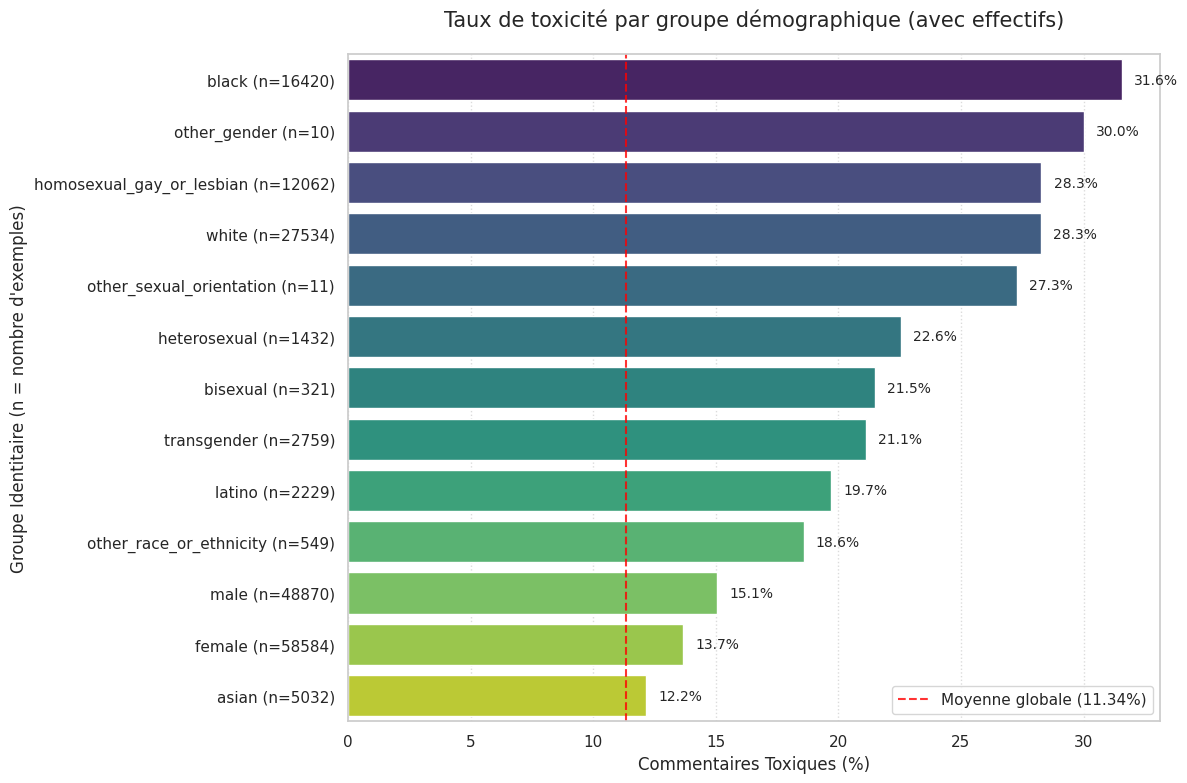

In [175]:
plt.figure(figsize=(12, 8))
global_toxic_rate = df['is_toxic'].mean() * 100

plot = sns.barplot(
    data=df_bias, 
    x='Taux de toxicité (%)', 
    y='Groupe', 
    palette='viridis'
)

plt.axvline(global_toxic_rate, color='red', linestyle='--', alpha=0.8, 
            label=f'Moyenne globale ({global_toxic_rate:.2f}%)')

plt.title('Taux de toxicité par groupe démographique (avec effectifs)', fontsize=15, pad=20)
plt.xlabel('Commentaires Toxiques (%)', fontsize=12)
plt.ylabel('Groupe Identitaire (n = nombre d\'exemples)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(axis='x', linestyle=':', alpha=0.7)

for i, p in enumerate(plot.patches):
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height()/2, 
             f'{width:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Pour tous les groupes démographiques sélectionnés, le taux de textes toxiques est toujours supérieur à la moyenne des textes. Le taux atteint même 3 fois le taux moyen pour les groupes 'black', 'homosexual', 'white' ('other_sexual_orientation' et 'other_gender' sont trop peu représentés pour conclure).